<a href="https://colab.research.google.com/github/Priya-DharshiniRamesh/24ADI006_DEEP-LEARNING/blob/main/DL_EXP_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**DEEP LEARNING -24ADI006**

**EXPT NO: 5	IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION**

**Name:Priya Dharshini R**\
**Roll no:24BAD092**

**AIM**

To implement a Recurrent Neural Network (RNN) for text generation and evaluate its ability to generate meaningful text by predicting the next word in a sequence.

**SOFTWARE REQUIREMENTS**

•	Python

•	TensorFlow or keras or PyTorch

•	Google Colab

•	GitHub

•	Numpy

•	Matplotlib



**TASK A: DATASET PREPARATION**

**Perform the following tasks:**

•	Load the Tiny Shakespeare dataset from Hugging Face.

•	Explore the dataset and examine the text samples.

•	Convert the text into lowercase (if required).

•	Tokenize the text into individual words.

•	Build a vocabulary and assign a unique integer index to each word.

•	Generate input sequences for next-word prediction.

•	Apply sequence padding to obtain inputs of equal length.

•	Split the prepared sequences into training and validation datasets.



In [ ]:
import os
import random
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Name: Priya Dharshini R")
print("Roll No: 24BAD092")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

response = requests.get(url)
response.raise_for_status()

train_text = response.text

print("Dataset loaded successfully")
print("Number of characters:", len(train_text))
print("\nFirst 1000 characters:\n")
print(train_text[:1000])

lines = [line.strip() for line in train_text.splitlines() if line.strip()]

print("\nNumber of non-empty lines:", len(lines))
print("\nFirst 10 non-empty lines:")

for i, line in enumerate(lines[:10], start=1):
    print(f"{i}: {line}")

text = train_text.lower()
text = re.sub(r"[^a-z'\s]", " ", text)
text = re.sub(r"\s+", " ", text).strip()

print("\nCleaned text sample:\n")
print(text[:1000])

tokenizer = Tokenizer(
    filters="",
    lower=False,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

word_to_index = tokenizer.word_index

index_to_word = {
    index: word
    for word, index in word_to_index.items()
}

vocab_size = len(word_to_index) + 1

token_ids = tokenizer.texts_to_sequences([text])[0]

print("\nVocabulary size:", vocab_size)
print("Total word tokens:", len(token_ids))

print("\nFirst 20 vocabulary entries:")

for word, idx in list(word_to_index.items())[:20]:
    print(f"{word:15s} -> {idx}")

MAX_CONTEXT = 10

sequences = []

for i in range(1, len(token_ids)):
    start = max(0, i - MAX_CONTEXT)
    sequence = token_ids[start:i + 1]
    sequences.append(sequence)

max_sequence_len = MAX_CONTEXT + 1

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_len,
    padding="pre",
    truncating="pre"
)

print("\nNumber of sequences:", len(padded_sequences))
print("Padded sequence shape:", padded_sequences.shape)

print("\nExample padded sequences:")
print(padded_sequences[:5])

X = padded_sequences[:, :-1]
y = padded_sequences[:, -1]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("\nTraining samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Input sequence length:", X_train.shape[1])

print("\nName: Priya Dharshini R")
print("Roll No: 24BAD092")

Name: Priya Dharshini R
Roll No: 24BAD092
TensorFlow version: 2.20.0
Dataset loaded successfully
Number of characters: 1115394

First 1000 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is 

**TASK B: IMPLEMENTING THE RNN MODEL**

**Perform the following tasks:**

•	Create an Embedding layer to convert words into dense vector representations.

•	Add a Simple RNN layer to learn sequential dependencies in the text.

•	Add a Dense output layer with Softmax activation for next-word prediction.

•	Compile the model using an appropriate optimizer and loss function.

•	Display the model architecture and summary.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

EMBEDDING_DIM = 100
RNN_UNITS = 128

model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_CONTEXT,
        mask_zero=True
    ),
    SimpleRNN(RNN_UNITS),
    Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_CONTEXT))

model.summary()

print("Name: Priya Dharshini R")
print("Roll No: 24BAD092")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 10, 100)        │     1,263,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        29,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12633)          │     1,629,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,922,269 (11.15 MB)

 Trainable params: 2,922,269 (11.15 MB)

 Non-trainable params: 0 (0.00 B)

Name: Priya Dharshini R
Roll No: 24BAD092


**TASK C: RNN MODEL TRAINING AND PERFORMANCE EVALUATION**

**Perform the following tasks:**

•	Train the RNN model using the prepared training dataset.

•	Validate the model using the validation dataset.

**Record:**

o	Training accuracy

o	Validation accuracy

o	Training loss

o	Validation loss

**Visualize:**

o	Accuracy vs. Epoch

o	Loss vs. Epoch



Name: Priya Dharshini R
Roll No: 24BAD092
Epoch 1/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 70s 54ms/step - accuracy: 0.0426 - loss: 6.7863 - val_accuracy: 0.0666 - val_loss: 6.4778
Epoch 2/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.0784 - loss: 6.1255 - val_accuracy: 0.0812 - val_loss: 6.3199
Epoch 3/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.0936 - loss: 5.7690 - val_accuracy: 0.0865 - val_loss: 6.3153
Epoch 4/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 71s 56ms/step - accuracy: 0.1058 - loss: 5.4790 - val_accuracy: 0.0875 - val_loss: 6.3647
Epoch 5/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 79s 53ms/step - accuracy: 0.1182 - loss: 5.2174 - val_accuracy: 0.0857 - val_loss: 6.4403
Epoch 6/15
1276/1276 ━━━━━━━━━━━━━━━━━━━━ 68s 53ms/step - accuracy: 0.1334 - loss: 4.9736 - val_accuracy: 0.0838 - val_loss: 6.5310

Training Accuracy   : 0.1334
Validation Accuracy : 0.0838
Training Loss       : 4.9736
Validation Loss     : 6.5310


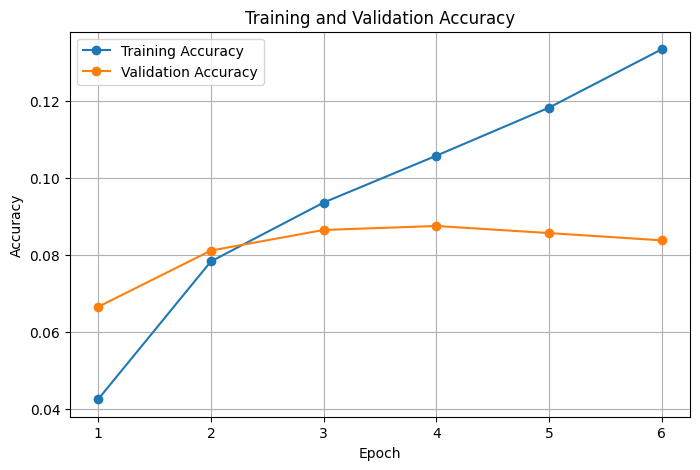

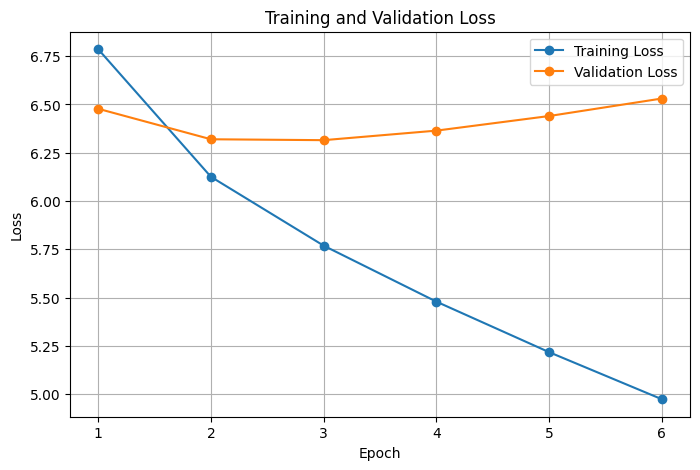

Name: Priya Dharshini R
Roll No: 24BAD092


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("Name: Priya Dharshini R")
print("Roll No: 24BAD092")

EPOCHS = 15
BATCH_SIZE = 128

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    verbose=1
)

final_train_accuracy = history.history["accuracy"][-1]
final_val_accuracy = history.history["val_accuracy"][-1]

final_train_loss = history.history["loss"][-1]
final_val_loss = history.history["val_loss"][-1]

print("\nTraining Accuracy   :", f"{final_train_accuracy:.4f}")
print("Validation Accuracy :", f"{final_val_accuracy:.4f}")
print("Training Loss       :", f"{final_train_loss:.4f}")
print("Validation Loss     :", f"{final_val_loss:.4f}")

epochs_ran = range(
    1,
    len(history.history["accuracy"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_ran,
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()



plt.figure(figsize=(8, 5))

plt.plot(
    epochs_ran,
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_ran,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Name: Priya Dharshini R")
print("Roll No: 24BAD092")

**TASK D: DEEP LEARNING EXPERIMENT MANAGEMENT**

**Perform the following tasks:**

•	Provide a seed word or sentence as input to the trained model.

•	Generate text by repeatedly predicting the next word in the sequence.

•	Produce multiple text samples using different seed inputs.

•	Compare the generated text for coherence and contextual relevance.

•	Document the observations and upload the notebook to GitHub.


In [ ]:
def sample_next_word(probabilities, temperature=0.8):

    probabilities = np.asarray(
        probabilities
    ).astype("float64")

    probabilities = np.log(
        probabilities + 1e-10
    ) / temperature

    probabilities = np.exp(probabilities)

    probabilities = probabilities / np.sum(
        probabilities
    )

    return np.random.choice(
        len(probabilities),
        p=probabilities
    )


def generate_text(
    seed_text,
    next_words=40,
    temperature=0.8
):

    generated_text = seed_text.lower().strip()

    for _ in range(next_words):

        cleaned_seed = re.sub(
            r"[^a-z'\s]",
            " ",
            generated_text
        )

        cleaned_seed = re.sub(
            r"\s+",
            " ",
            cleaned_seed
        ).strip()

        token_list = tokenizer.texts_to_sequences(
            [cleaned_seed]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=MAX_CONTEXT,
            padding="pre",
            truncating="pre"
        )

        predicted_probabilities = model.predict(
            token_list,
            verbose=0
        )[0]

        predicted_probabilities[0] = 0

        predicted_index = sample_next_word(
            predicted_probabilities,
            temperature=temperature
        )

        predicted_word = index_to_word.get(
            predicted_index
        )

        if (
            predicted_word is None
            or predicted_word == "<OOV>"
        ):
            continue

        generated_text += " " + predicted_word

    return generated_text


seeds = [
    "to be or not to be",
    "romeo",
    "my lord",
    "the king"
]

for seed in seeds:

    print("=" * 90)
    print("Seed:", seed)
    print("Generated text:")

    print(
        generate_text(
            seed,
            next_words=40,
            temperature=0.8
        )
    )

    print()



seed = "to be or not to be"

for temperature in [0.5, 0.8, 1.2]:

    print("=" * 90)
    print("Temperature =", temperature)

    print(
        generate_text(
            seed,
            next_words=40,
            temperature=temperature
        )
    )

    print()


model.save("tiny_shakespeare_rnn.keras")

print("Model saved as tiny_shakespeare_rnn.keras")
print("Name: Priya Dharshini R")
print("Roll No: 24BAD092")

Seed: to be or not to be
Generated text:
to be or not to be revenged yet him to seek my lady's chance and hath coming well with you will had not we coriolanus be my lord i will be more but that i must not corioli i fly to the duke of york duke

Seed: romeo
Generated text:
romeo tell them your blindfold rose i am sure i am a doubt of the country of me it not warwick well else how he did his mind northumberland sir you duke of york and good same sake i'll be clown

Seed: my lord
Generated text:
my lord the ministers that i must go my counsel is not children we am a dream o' the prince richard come to love thee ready it cannot hear you surely to be baptista i am thee all to he in the

Seed: the king
Generated text:
the king on't with that the nobility falsely as it shall be gone by your foe this tear his saint against the gentle worst cannot didst for the blinding summer names or in the mourning blood to lose thy horse for all

Temperature = 0.5
to be or not to be a little of my house and